# A Physiologically Based Pharmacokinetic Model

## Model Description

Like any pharmacokinetic (PK) model, a physiologically based pharmacokinetic (PBPK) model is a mathematical description of the absorption, distribution, metabolism, and excretion of a substance by an organism. PBPK models differ from classical PK models in that many of their parameters describe actual anatomical and physiological properties of the organism, such as volumes of and blood flow rates to various organs and tissues. Figure 1 shows a schematic representation of a relatively simple PBPK model for "Substance X."

![Pharmacokinetic Model](pbpk_basic_model_schematic.png)

Substance X can enter the body through oral and/or intravenous routes and it is eliminated via saturable metabolism in the liver. The kinetics of distribution are assumed to be "perfusion limited," so concentrations in different tissues depend on steady state concentration ratios, or "partition coefficients," for each type of tissue.

The state variables for the PBPK model include:
* $A_\textrm{G}$, the amount (of Substance X) in the gut lumen (mg);
* $A_\textrm{L}$, the amount in the liver (mg);
* $A_\textrm{F}$, the amount in the fat (mg);
* $A_\textrm{AB}$, the amount in the arterial blood (mg);
* $A_\textrm{VB}$, the amount in the venous blood (mg);
* $A_\textrm{R}$, the amount in the rest of body (mg);
* $A_\textrm{dose}$, the cumulative amount that has been dosed (mg); and
* $A_\textrm{m}$, the cumulative amount that has been metabolized (mg).

The anatomical and physiological parameters are:

* $M$, the body mass of the organism (kg);
* $Q_\textrm{CC}$, the cardiac output constant (L/h/kg${}^{0.75}$, i.e., liters per hour per kg of body mass to the 3/4 power);
* $Q_\textrm{LC}$, the constant fractional blood flow to the liver;
* $Q_\textrm{FC}$, the constant fractional blood flow to the fat;
* $V_\textrm{LC}$, the constant volume fraction of body mass that is the liver (L/kg);
* $V_\textrm{FC}$, the constant volume fraction of body mass that is the fat (L/kg);
* $V_\textrm{ABC}$, the constant volume fraction of body mass that is the arterial blood (L/kg); and
* $V_\textrm{VBC}$, the constant volume fraction of body mass that is the venous blood (L/kg).

Values for anatomical and physiological parameters for rats and humans are shown in the following table.

| Parameter         | Units             | Rat Value | Human Value |
|-------------------|:-----------------:|:---------:|:-----------:|
| $M$               | kg                | 0.25      | 80          |
| $Q_\textrm{CC}$  | L/h/kg${}^{0.75}$ | 15        | 15          |
| $Q_\textrm{LC}$  | --                | 0.21      | 0.26        |
| $Q_\textrm{FC}$  | --                | 0.06      | 0.05        |
| $V_\textrm{LC}$  | L/kg              | 0.04      | 0.02        |
| $V_\textrm{FC}$  | L/kg              | 0.07      | 0.21        |
| $V_\textrm{ABC}$ | L/kg              | 0.02      | 0.02        |
| $V_\textrm{VBC}$ | L/kg              | 0.05      | 0.05        |

The chemical-specific parameters for Substance X are:	

* $P_\textrm{L} = 3.5$, the liver-to-blood partition coefficient;
* $P_\textrm{F} = 86.5$, the fat-to-blood partition coefficient;
* $P_\textrm{R} = 2.3$, the rest-of-body-to-blood partition coefficient;
* $V_\textrm{maxC} = 10.0$, the maximum metabolic rate constant (mg/h/kg${}^{0.75}$);
* $K_\textrm{m} = 6.0$, the affinity constant for saturable metabolism (mg/L); and
* $k_\textrm{abs} = 1.25$, the first-order oral absorption rate constant (h${}^{-1}$).

In general, chemical-specific parameters can have different values for different animal species but, in this case, we assume that they have the same values for rats and humans.

The dosing parameters are:

* $D_\textrm{oral}$, the body mass normalized daily oral dose rate (mg/kg/d); and
* $D_\textrm{IV}$, the body mass normalized daily intravenous dose rate (mg/kg/d).

Note that the dosing rates are given in units of mg of Substance X per kg of body mass per day.

To construct the state equations for the model, the following “calculated parameters” are needed:

* $Q_\textrm{C} = Q_\textrm{CC} \cdot M^{0.75}$, cardiac output (L/h);
* $Q_\textrm{L} = Q_\textrm{LC} \cdot Q_\textrm{C}$, blood flow rate to the liver (L/h);
* $Q_\textrm{F} = Q_\textrm{FC} \cdot Q_\textrm{C}$, blood flow rate to the fat (L/h);
* $Q_\textrm{RC} = 1.0 - (Q_\textrm{LC} + Q_\textrm{FC})$, constant fractional blood flow to the rest of body;
* $Q_\textrm{R} = Q_\textrm{RC} \cdot Q_\textrm{C}$, blood flow rate to the rest of body (L/h);
* $V_\textrm{L} = V_\textrm{LC} \cdot M$, volume of the liver (L);
* $V_\textrm{F} = V_\textrm{FC} \cdot M$, volume of the fat (L);
* $V_\textrm{AB} = V_\textrm{ABC} \cdot M$, volume of the arterial blood (L);
* $V_\textrm{VB} = V_\textrm{VBC} \cdot M$, volume of the venous blood (L);
* $V_\textrm{RC} = 1.0 - (V_\textrm{LC} + V_\textrm{FC} + V_\textrm{ABC} + V_\textrm{VBC})$, constant volume fraction of body mass that is the rest of body (L/kg);
* $V_\textrm{R} = V_\textrm{RC} \cdot M$, volume of the rest of body (L);
* $V_\textrm{max} = V_\textrm{maxC} \cdot M^{0.75}$, maximum rate of metabolism (mg/h);
* $R_\textrm{oral} = D_\textrm{oral} \cdot M / 24$, the oral dose rate (mg/h); and
* $R_\textrm{IV} = D_\textrm{IV} \cdot M / 24$, the intravenous dose rate (mg/h);

In addition to the model parameters, the following time-varying quantities are needed to construct the state equations:

* $C_\textrm{L}(t) = \frac{A_\textrm{L}(t)}{V_\textrm{L}}$, the concentration (of Substance X) in the liver (mg/L) at time $t$;
* $C_\textrm{F}(t) = \frac{A_\textrm{F}(t)}{V_\textrm{F}}$, the concentration in the fat (mg/L) at time $t$;
* $C_\textrm{AB}(t) = \frac{A_\textrm{AB}(t)}{V_\textrm{AB}}$, the concentration in the arterial blood (mg/L) at time $t$;
* $C_\textrm{VB}(t) = \frac{A_\textrm{VB}(t)}{V_\textrm{VB}}$, the concentration in the venous blood (mg/L) at time $t$;
* $C_\textrm{R}(t) = \frac{A_\textrm{R}(t)}{V_\textrm{R}}$, the concentration in the rest of body (mg/L) at time $t$;
* $R_\textrm{m}(t) = \frac{V_\textrm{max} \cdot C_\textrm{L}(t) / P_\textrm{L}}{  K_\textrm{m} + C_\textrm{L}(t) / P_\textrm{L}}$, the rate of metabolism in the liver (mg/h) at time $t$; and
* $R_\textrm{abs}(t) = k_\textrm{abs} \cdot A_\textrm{G}(t)$, the rate of absorption from the gut lumen to the liver (mg/h) at time $t$.

The state equations for the PBPK model are:

* $\frac{\textrm{d}}{\textrm{d}t} A_\textrm{G}(t) = R_\textrm{oral} - R_\textrm{abs}(t)$;
* $\frac{\textrm{d}}{\textrm{d}t} A_\textrm{L}(t) = Q_\textrm{L} \cdot \left( C_\textrm{AB}(t) - \frac{C_\textrm{L}(t)}{P_\textrm{L}} \right) + R_\textrm{abs}(t) - R_\textrm{m}(t)$;
* $\frac{\textrm{d}}{\textrm{d}t} A_\textrm{F}(t) = Q_\textrm{F} \cdot \left( C_\textrm{AB}(t) - \frac{C_\textrm{F}(t)}{P_\textrm{F}} \right)$;
* $\frac{\textrm{d}}{\textrm{d}t} A_\textrm{AB}(t) = Q_\textrm{C} \cdot \left( C_\textrm{VB}(t) - C_\textrm{AB}(t) \right)$;
* $\frac{\textrm{d}}{\textrm{d}t} A_\textrm{VB}(t) = Q_\textrm{L} \cdot \frac{C_\textrm{L}(t)}{P_\textrm{L}} + Q_\textrm{F} \cdot \frac{C_\textrm{F}(t)}{P_\textrm{F}} + Q_\textrm{R} \cdot \frac{C_\textrm{R}(t)}{P_\textrm{R}} - Q_\textrm{C} \cdot C_\textrm{VB}(t) + R_\textrm{IV}$;
* $\frac{\textrm{d}}{\textrm{d}t} A_\textrm{R}(t) = Q_\textrm{R} \cdot \left( C_\textrm{AB}(t) - \frac{C_\textrm{R}(t)}{P_\textrm{R}} \right)$;
* $\frac{\textrm{d}}{\textrm{d}t} A_\textrm{dose}(t) = R_\textrm{oral} + R_\textrm{IV}$; and
* $\frac{\textrm{d}}{\textrm{d}t} A_\textrm{m}(t) = R_\textrm{m}(t)$.

In order to solve an initial value problem for the PBPK model, one needs to provide the values of the basic parameters (but not the calculated parameters) and initial values for all the state variables.

## MCSim Model Specification

We used the [GNU MCSim](https://www.gnu.org/software/mcsim/) model specification language to implement the simple PBPK model for Substance X. The complete MCSim model specification file for this model, `pbpk_simple.model`, can be found in the `data` subdirectory of the **PyMCSimMod** package source directory.

In addition to the state variables that have already been described, we included a state variable that represents the area under the venous blood concentration vs. time curve (AUC), as this is a quantity that is often computed in pharmacokinetic analyses. The AUC for the period from time $0$ to time $t$ is given by $\textrm{AUC}(t) = \int_0^t C_\textrm{VB}(\tau) \, \textrm{d}\tau$ and thus the state equation for this quantity is

$$
\begin{equation}
  \frac{\textrm{d}}{\textrm{d}t} \textrm{AUC}(t) = C_\textrm{VB}(t).
\end{equation}
$$

Also, in addition to the time-varying quantities previously mentioned, the model includes another output variable,

$$
\begin{equation}
  A_\textrm{tot}(t) = A_\textrm{dose}(t) - \left( A_\textrm{G}(t) + A_\textrm{F}(t) + A_\textrm{AB}(t) + A_\textrm{VB}(t) + A_\textrm{R}(t) \right) - A_\textrm{m}(t),
\end{equation}
$$

that represents the total amount of substance that has been "lost" vs. time. This amount is calculated as [total (cumulative) amount that has entered in the organism] - [total amount currently in the organism] - [total (cumulative) amount that has been eliminated from the organism]. Therefore, if the model "conserves mass" as it should, the value of $A_\textrm{tot}(t)$ should be zero (or very close to zero for numerical solutions to an IVP) at all times $t$.

Note that the model specification file uses text symbols to represent the state variables, output variables, and parameters in the model. For example, the state variable $A_\textrm{L}$ is represented by the text symbol `A_L`, the output variable $C_\textrm{L}$ is represented by the text symbol `C_L`, and the parameter $Q_\textrm{LC}$ is represented by the text symbol `Q_LC`.

## Building the Model

First, we load the **PyMCSimMod** package as follows.

In [1]:
%load_ext autoreload
%autoreload 2

from pymcsimmod import create_model

Using the following commands, we create a model object (i.e., an instance of the `ScipyModel` class) using the model specification file `pbpk_simple.model` that is included in the **PyMCSimMod** package.

In [2]:
import importlib.resources
with importlib.resources.path('pymcsimmod.data', 'pbpk_simple.model') as filename:
    pbpk_mod = create_model(filename, backend="scipy")
    #pbpk_mod = create_model(filename, backend="jax")

## Verifying Conservation of Mass

We can demonstrate that the PBPK model for Substance X conserves mass by performing a simulation in which a rat is orally administered 1 mg/kg/d of Substance X and plotting total amount of substance lost, $A_\textrm{tot}(t)$, vs. time, $t$.

The default values of the anatomical and physiological model parameters that are provided in the model specification file, `pbpk_simple.model`, are for a rat, and these are the values that are assigned to the parameters when one initiates the model. This can be verified by examining the attribute `parameters` of the `Model` object `pbpk_mod` as follows.

In [3]:
pbpk_mod.parameters

{'M': 0.25,
 'Q_CC': 15.0,
 'Q_LC': 0.21,
 'Q_FC': 0.06,
 'V_LC': 0.04,
 'V_FC': 0.07,
 'V_ABC': 0.02,
 'V_VBC': 0.05,
 'P_L': 3.5,
 'P_F': 86.5,
 'P_R': 2.3,
 'V_maxC': 10.0,
 'K_m': 6.0,
 'k_abs': 1.25,
 'D_oral': 0.0,
 'D_IV': 0.0,
 'Q_C': 5.303300858899107,
 'Q_L': 1.1136931803688124,
 'Q_F': 0.31819805153394637,
 'Q_RC': 0.73,
 'Q_R': 3.8714096269963476,
 'V_L': 0.01,
 'V_F': 0.0175,
 'V_AB': 0.005,
 'V_VB': 0.0125,
 'V_RC': 0.8200000000000001,
 'V_R': 0.20500000000000002,
 'V_max': 3.5355339059327378,
 'R_oral': 0.0,
 'R_IV': 0.0}

We want to perform a simulation in which a rat is orally administered 1 mg/kg/d of Substance X, so we will change the value of the parameter $D_\textrm{oral}$ from 0 to 1.

In [4]:
pbpk_mod.update_constants(D_oral = 1) # 1 mg/kg/d dose

Now, if we examine the values of the model parameters, we can see that the body mass normalized oral administration rate (represented by $D_\textrm{oral}$ and `D_oral`) has been updated from 0 to 1 mg/kg/d and the actual oral administration rate (represented by (represented by $R_\textrm{oral}$ and `R_oral`), which is a calculated parameter, has also been updated (from 0 to approximately 0.0104 mg/h).

In [5]:
pbpk_mod.parameters

{'M': 0.25,
 'Q_CC': 15.0,
 'Q_LC': 0.21,
 'Q_FC': 0.06,
 'V_LC': 0.04,
 'V_FC': 0.07,
 'V_ABC': 0.02,
 'V_VBC': 0.05,
 'P_L': 3.5,
 'P_F': 86.5,
 'P_R': 2.3,
 'V_maxC': 10.0,
 'K_m': 6.0,
 'k_abs': 1.25,
 'D_oral': 1,
 'D_IV': 0.0,
 'Q_C': 5.303300858899107,
 'Q_L': 1.1136931803688124,
 'Q_F': 0.31819805153394637,
 'Q_RC': 0.73,
 'Q_R': 3.8714096269963476,
 'V_L': 0.01,
 'V_F': 0.0175,
 'V_AB': 0.005,
 'V_VB': 0.0125,
 'V_RC': 0.8200000000000001,
 'V_R': 0.20500000000000002,
 'V_max': 3.5355339059327378,
 'R_oral': 0.010416666666666666,
 'R_IV': 0.0}

We can examine the initial conditions for the state variables in the model using the following command.

In [6]:
print(pbpk_mod.Y0)

{'A_G': 0.0, 'A_L': 0.0, 'A_F': 0.0, 'A_AB': 0.0, 'A_VB': 0.0, 'A_R': 0.0, 'A_dose': 0.0, 'A_m': 0.0, 'AUC': 0.0}


As stated in the model specification file, `pbpk_simple.model`, the default values for the initial conditions are all zero.

Suppose that we want to perform a simulation and generate results for 100 hours following oral administration with an output resolution of 0.1 hours. We can create a vector of desired output times (i.e., $t = 0, 0.1, 0.2, \ldots, 100.0$) using the following command.

In [7]:
import numpy as np

# Define output times for simulation.
times = np.arange(start = 0, stop = 100, step = 0.1)

# Run simulation.
results = pbpk_mod.run_model(times)
out_oral = results.dataframe

Finally, we can plot the total amount lost vs. time using the following command.

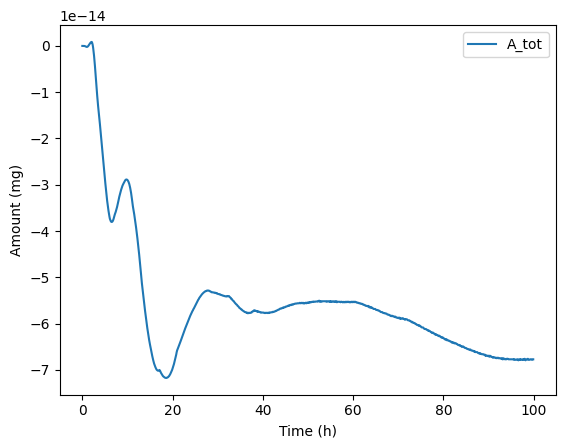

In [8]:
ax = results.plot_results(variables='A_tot', xlabel='Time (h)', ylabel='Amount (mg)')

Note that the total amount lost is close to zero (less than 10${}^{-12}$) at all time points examined. The degree of "closeness" to zero is determined by the numerical precision of the ODE solver and the integration method used for the solver. When running a `ScipyModel`, the integration method can be changed using the `method` keyword argument.

## Verifying Conservation of Flow

We can also verify that the total blood flow to the non-blood compartments in our PBPK model equals the total cardiac output using the following commands.

In [9]:
print(f"Total blood flow to compartments: {pbpk_mod.parameters['Q_L'] + pbpk_mod.parameters['Q_F'] + pbpk_mod.parameters['Q_R']:0.5f} L/h")
print(f"Total cardiac output: {pbpk_mod.parameters['Q_C']:0.5f} L/h")

Total blood flow to compartments: 5.30330 L/h
Total cardiac output: 5.30330 L/h


## Examining the Simulation Results

After performing a simulation and storing the results (in this case, in `out_oral`), we can create visual representations of these results. For example, we can plot the venous blood concentration vs. time using the following commands.

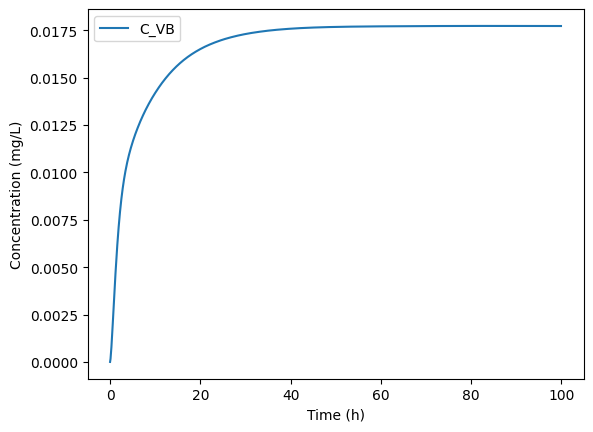

In [10]:
ax = results.plot_results(variables='C_VB', xlabel='Time (h)', ylabel='Concentration (mg/L)')

We can plot the concentrations in all non-blood compartments (on a logarithmic scale) as follows.

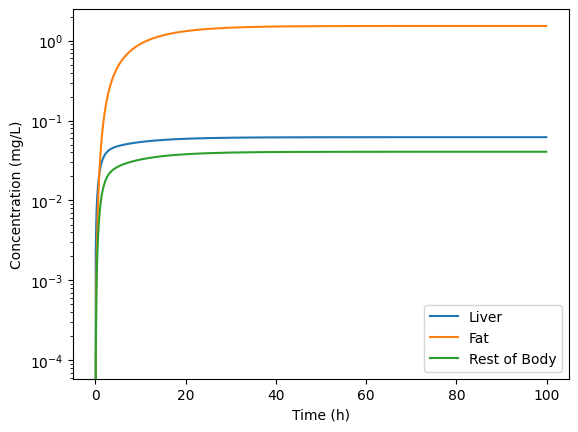

In [11]:
ax = results.plot_results(variables=['C_L', 'C_F', 'C_R'], labels={'C_L': 'Liver', 'C_F': 'Fat', 'C_R': 'Rest of Body'}, xlabel='Time (h)', ylabel='Concentration (mg/L)')
ax.set_yscale('log')